# Project 2: Motor Fault Classifier — Full Pipeline

Use the SECOM or AI4I dataset (UCI). Build a
full classification pipeline: load data, handle
missing values, scale, train Logistic Regression
+ Decision Tree + Random Forest. Plot a sideby-side confusion matrix for all three. Save the
best model using joblib for reuse.

### Skills: sklearn Pipeline, RandomForest, joblib,confusion matrix, classification_report

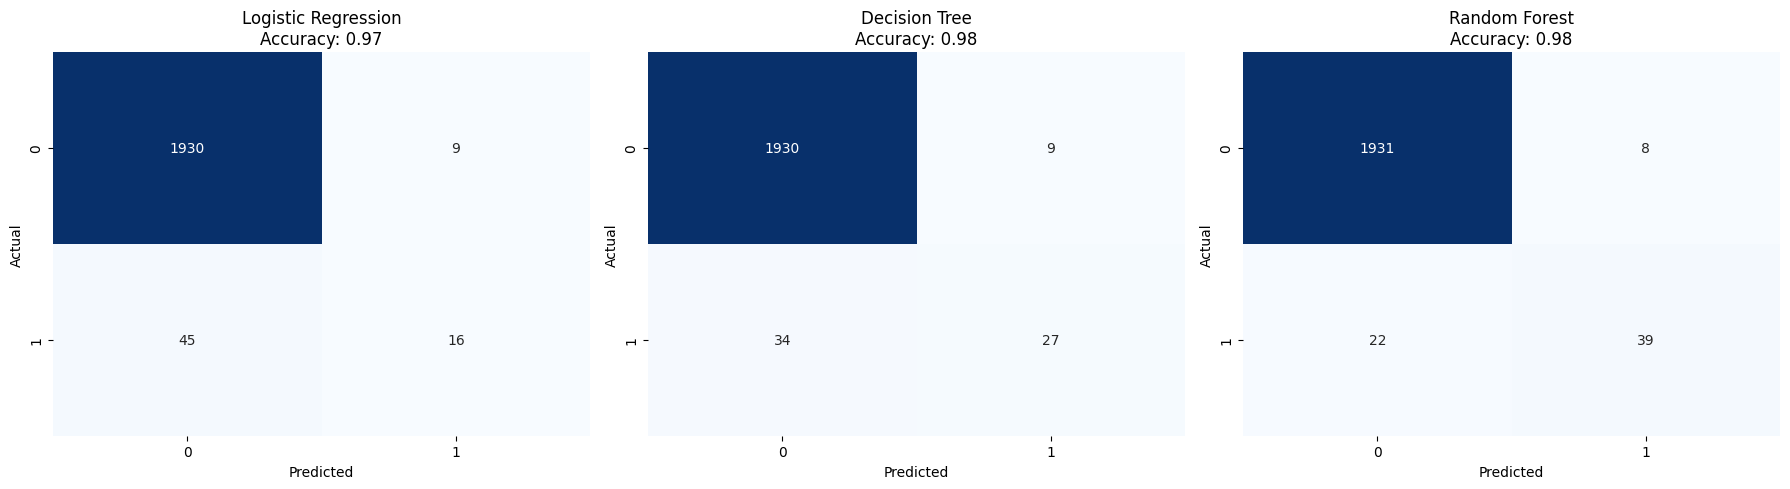

Successfully saved Random Forest as the best model.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import joblib

# --- 1. Load Data ---
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

# Features: Type, Air temp, Process temp, Rotational speed, Torque, Tool wear
# Target: Machine failure
X = df[['Air temperature [K]', 'Process temperature [K]', 
        'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']]
y = df['Machine failure']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. Create Pipelines ---
# We define a common preprocessing step: Impute missing values then Scale
def create_pipeline(classifier):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', classifier)
    ])

models = {
    "Logistic Regression": create_pipeline(LogisticRegression()),
    "Decision Tree": create_pipeline(DecisionTreeClassifier(max_depth=5)),
    "Random Forest": create_pipeline(RandomForestClassifier(n_estimators=100))
}

# --- 3. Train and Evaluate ---
results = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, pipeline) in enumerate(models.items()):
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = report['accuracy']
    
    # Confusion Matrix Visualization
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False)
    axes[i].set_title(f"{name}\nAccuracy: {report['accuracy']:.2f}")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# --- 4. Save the Best Model ---
# Find the model name with the highest accuracy
best_model_name = max(results, key=results.get)
joblib.dump(models[best_model_name], 'best_motor_classifier.pkl')

print(f"Successfully saved {best_model_name} as the best model.")